# Project : Digit Recognition

In [65]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical   

In [2]:
df=pd.read_csv('/Users/sanjayduduka/Number Recognition/mnist_train 8.12.11 PM.csv')
df_test=pd.read_csv('/Users/sanjayduduka/Number Recognition/mnist_test.csv')
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [4]:
df.size

47100000

In [5]:
df.shape

(60000, 785)

In [6]:
df.isnull().sum().sum()

0

In [7]:
df.duplicated().sum()

0

# Data Preprocess
# Splitting to Train and Test

In [8]:
X_train = df.drop("label", axis=1).values
y_train = df["label"].values
X_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values
     

# Converting data in between 0 and 1

In [9]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Data Reshaping

In [10]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [11]:
y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)

# Perceptron Model building

In [12]:
perceptron= Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation="softmax")

])

2026-07-09 16:31:04.405663: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-07-09 16:31:04.405704: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-09 16:31:04.405712: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-09 16:31:04.405725: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-09 16:31:04.405733: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [13]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

In [14]:
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=10, batch_size=52, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/10
   1/1154 ━━━━━━━━━━━━━━━━━━━━ 3:41 192ms/step - accuracy: 0.0769 - loss: 2.4097

2026-07-09 16:31:04.632165: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1154/1154 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7819 - loss: 0.9300 - val_accuracy: 0.8664 - val_loss: 0.5635
Epoch 2/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8700 - loss: 0.5208 - val_accuracy: 0.8848 - val_loss: 0.4529
Epoch 3/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8830 - loss: 0.4500 - val_accuracy: 0.8933 - val_loss: 0.4079
Epoch 4/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8884 - loss: 0.4153 - val_accuracy: 0.8986 - val_loss: 0.3829
Epoch 5/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8933 - loss: 0.3936 - val_accuracy: 0.9024 - val_loss: 0.3659
Epoch 6/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8960 - loss: 0.3785 - val_accuracy: 0.9033 - val_loss: 0.3538
Epoch 7/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8991 - loss: 0.3671 - val_accuracy: 0.9061 - val_loss: 0.3443
Epoch 8/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9009 - loss: 0.3580 - val_accura

In [15]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]
acc_percp

0.9106000065803528

# ANN Model Building

In [16]:
ann_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])
     

In [17]:
ann_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [18]:
history_ann = ann_model.fit(X_train_img, y_train_cat, epochs=10, batch_size=52, 
                      validation_data=(X_test_img, y_test_cat),
                      verbose=1)

Epoch 1/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8791 - loss: 0.4331 - val_accuracy: 0.8801 - val_loss: 0.5082
Epoch 2/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8435 - loss: 0.9816 - val_accuracy: 0.7679 - val_loss: 2.3423
Epoch 3/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8178 - loss: 2.0943 - val_accuracy: 0.8417 - val_loss: 2.2051
Epoch 4/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8121 - loss: 3.5121 - val_accuracy: 0.8066 - val_loss: 4.4234
Epoch 5/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8046 - loss: 5.1897 - val_accuracy: 0.7735 - val_loss: 8.5378
Epoch 6/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8043 - loss: 6.9345 - val_accuracy: 0.7460 - val_loss: 13.0412
Epoch 7/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7998 - loss: 9.4260 - val_accuracy: 0.8485 - val_loss: 7.1989
Epoch 8/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8013 - loss:

In [50]:
acc_ann = ann_model.evaluate(X_test_img, y_test_cat, verbose=0)[1]
acc_ann

0.7628999948501587

# Reshaping Data

In [20]:
X_train_cnn = X_train.reshape(-1, 28, 28,1) #1 means channels => colors RGB and Gray scale , Gray Scale =1 , RGB=3
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [21]:
cnn = Sequential([
    #32=> Filters, kernal_size=filter size (Convolutional+Relu Layer 1)
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)), # 1=> Grayscale Channel
    MaxPooling2D(pool_size=(2,2)),  # Pooling size (2,2)=> size stride
     #64=> Filters, kernal_size=filter size (Convolutional+Relu Layer 2) 
    Conv2D(64, kernel_size=(3,3), activation="relu"), #Activation converts data in between 0 and 1
    MaxPooling2D(pool_size=(2,2)), 
    Flatten(), #Converts data into 1D matrix
    Dense(128, activation="relu"),  #Hidden Layer
    Dropout(0.5), #Dropout Reduces over fitting
    Dense(10, activation="softmax") #Output layer 
    #softmax because it is multicalss probel
])

In [22]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [32]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=10, batch_size=52, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9770 - loss: 0.1552 - val_accuracy: 0.9874 - val_loss: 0.1019
Epoch 2/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9766 - loss: 0.1888 - val_accuracy: 0.9877 - val_loss: 0.1001
Epoch 3/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9768 - loss: 0.2325 - val_accuracy: 0.9876 - val_loss: 0.1095
Epoch 4/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.9773 - loss: 0.2705 - val_accuracy: 0.9856 - val_loss: 0.1601
Epoch 5/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9789 - loss: 0.3063 - val_accuracy: 0.9857 - val_loss: 0.2224
Epoch 6/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9786 - loss: 0.3796 - val_accuracy: 0.9882 - val_loss: 0.2272
Epoch 7/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9796 - loss: 0.4222 - val_accuracy: 0.9861 - val_loss: 0.2832
Epoch 8/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9797 -

In [49]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]
acc_cnn

0.9898999929428101

# Model Performance Comparision

In [51]:

def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()
    

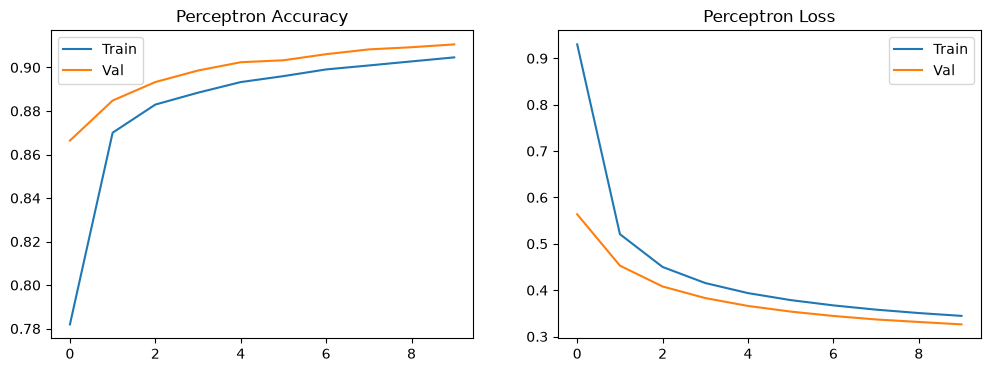

In [52]:
plot_training(history_percp, "Perceptron")

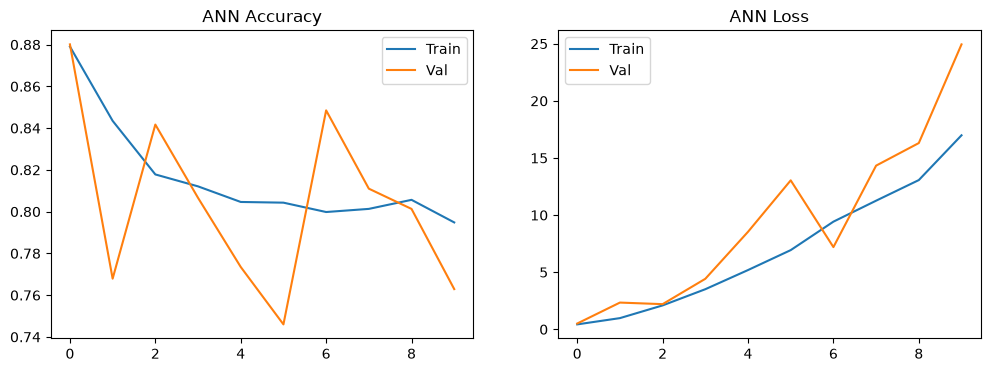

In [53]:
plot_training(history_ann, "ANN")

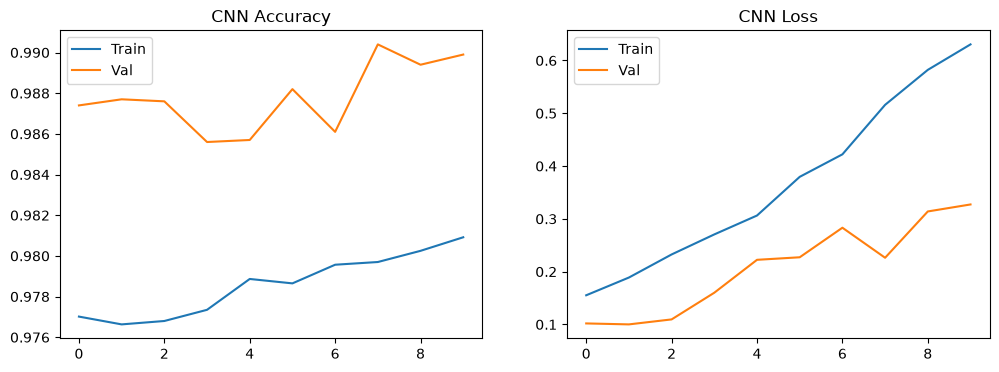

In [54]:
plot_training(history_cnn, "CNN")

# Validation Accuracy Comparison

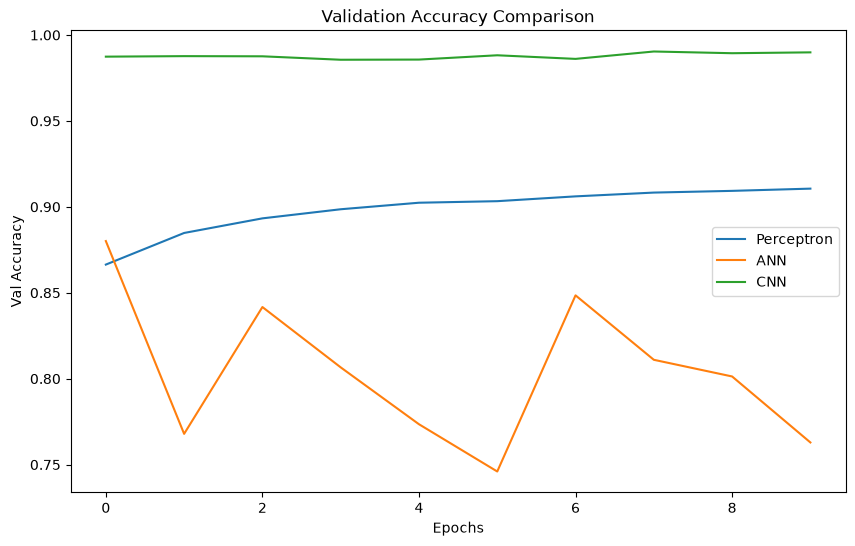

In [55]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [56]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


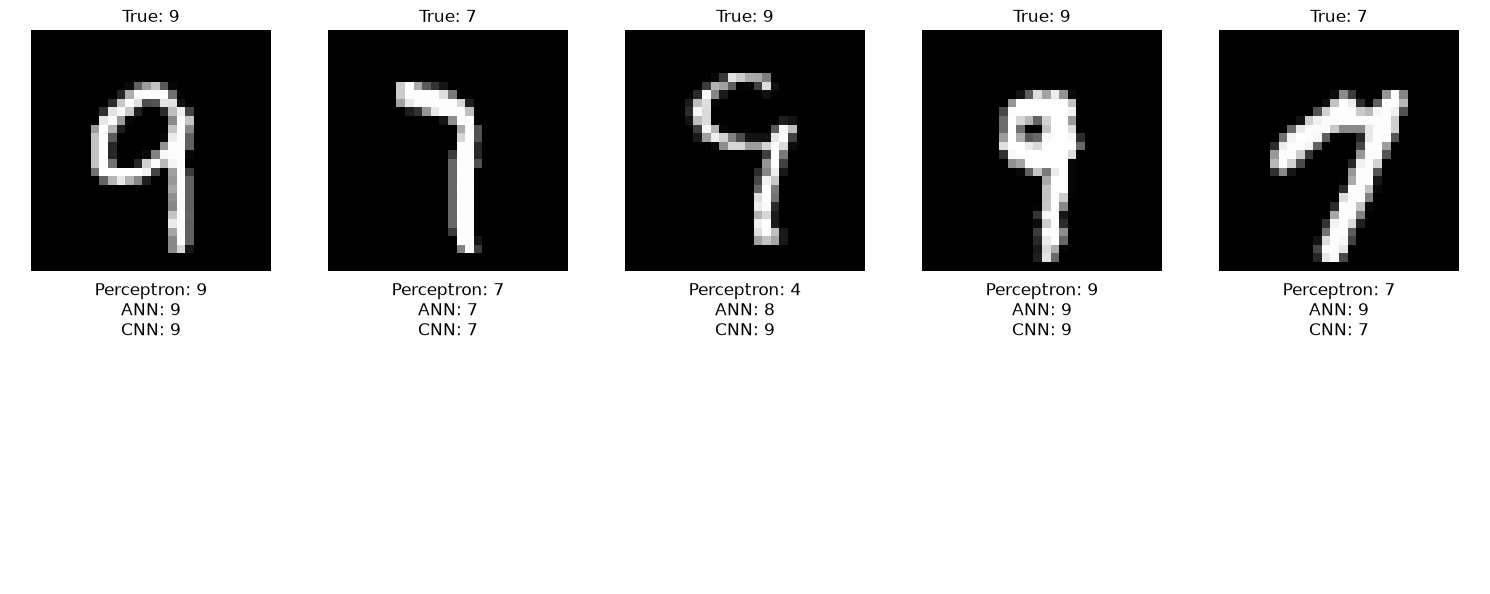

In [57]:
show_side_by_side([perceptron, ann_model, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


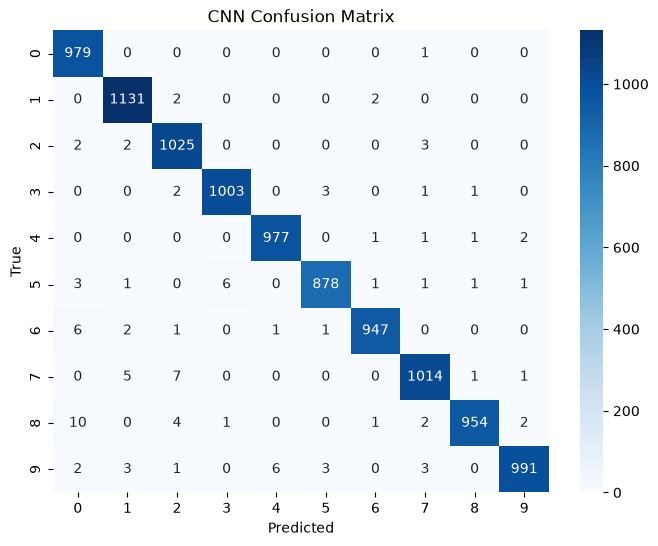

In [58]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

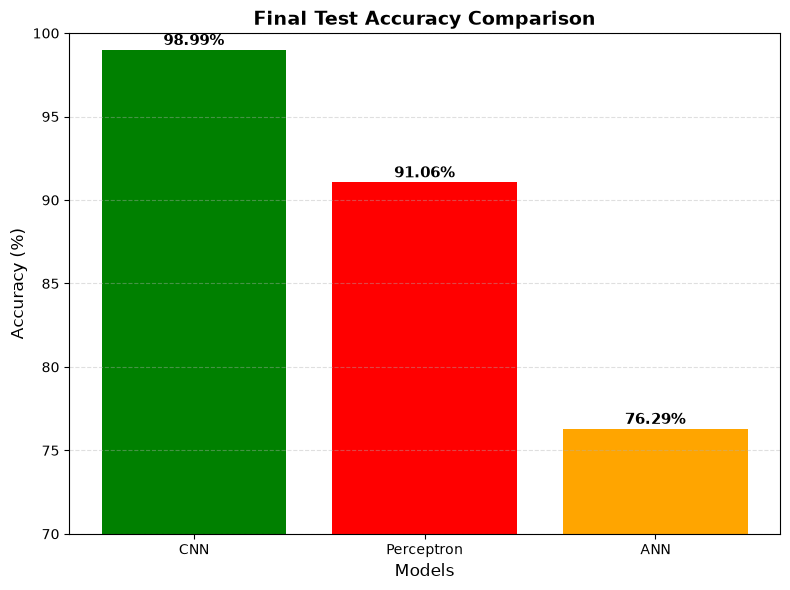

In [64]:
results = [
    ("CNN", acc_cnn * 100, "green"),
    ("Perceptron", acc_percp * 100, "red"),
    ("ANN", acc_ann * 100, "orange")
]


results = sorted(results, key=lambda x: x[1], reverse=True)

models = [x[0] for x in results]
accuracies = [x[1] for x in results]
colors = [x[2] for x in results]

plt.figure(figsize=(8,6))

bars = plt.bar(models, accuracies, color=colors)

plt.title("Final Test Accuracy Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)

plt.ylim(70, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)


for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        acc + 0.3,
        f"{acc:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()